In [145]:
import pandas as pd
import numpy as np
import seaborn as sns

In [146]:
df = pd.read_csv('../data/fake_reg.csv')

In [147]:
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


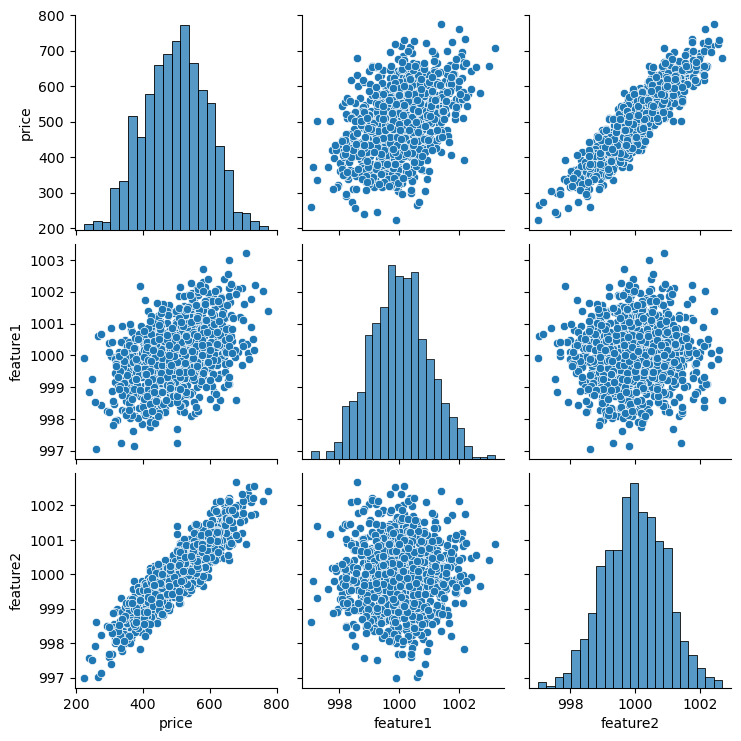

In [148]:
sns.pairplot(df)

In [149]:
from sklearn.model_selection import train_test_split

In [150]:
X = df[['feature1', 'feature2']].values

In [151]:
y = df['price'].values

In [152]:
X

array([[ 999.78755752,  999.7660962 ],
       [ 998.86161491, 1001.04240315],
       [1000.07026691,  998.84401463],
       ...,
       [1001.45164617,  998.84760554],
       [1000.77102275,  998.56285086],
       [ 999.2322436 , 1001.45140713]], shape=(1000, 2))

In [153]:
y

array([461.52792939, 548.13001146, 410.29716167, 540.38221981,
       546.02455292, 542.9836716 , 555.48566416, 417.56972453,
       373.14653122, 633.35029248, 624.24709206, 475.37241721,
       600.36844486, 532.83295175, 472.8353628 , 506.31229096,
       508.414406  , 610.4553519 , 323.65776198, 446.21230389,
       362.12270299, 433.41064026, 562.00257647, 637.30962074,
       522.80800754, 469.8028243 , 543.10992778, 565.43416994,
       530.03285381, 610.58016503, 482.55641188, 327.56004052,
       579.73083872, 448.42981468, 628.97709187, 536.79737216,
       570.06729543, 357.82557519, 612.08492732, 444.67970846,
       600.1186364 , 523.53312776, 512.94994495, 614.8813169 ,
       404.35303251, 643.68851807, 488.95660398, 443.20468572,
       514.47906638, 514.88174058, 325.05852217, 554.6620585 ,
       451.39140001, 587.67887726, 477.73749721, 574.51560687,
       548.9107991 , 528.69088356, 443.21100482, 397.88209319,
       355.79535223, 460.69478138, 534.7673737 , 537.60

In [154]:
type(X)

numpy.ndarray

In [155]:
type(y)

numpy.ndarray

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [157]:
X_train.shape

(700, 2)

In [158]:
X_test.shape

(300, 2)

In [159]:
from sklearn.preprocessing import MinMaxScaler

In [160]:
help(MinMaxScaler)

Help on class MinMaxScaler in module sklearn.preprocessing._data:

class MinMaxScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)
 |
 |  Transform features by scaling each feature to a given range.
 |
 |  This estimator scales and translates each feature individually such
 |  that it is in the given range on the training set, e.g. between
 |  zero and one.
 |
 |  The transformation is given by::
 |
 |      X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
 |      X_scaled = X_std * (max - min) + min
 |
 |  where min, max = feature_range.
 |
 |  This transformation is often used as an alternative to zero mean,
 |  unit variance scaling.
 |
 |  `MinMaxScaler` doesn't reduce the effect of outliers, but it linearly
 |  scales them down into a fixed range, where the largest occurring data point
 |  corresponds to the maximum value and the smallest one corresponds to

In [161]:
scaler = MinMaxScaler()

In [162]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [163]:
X_train = scaler.transform(X_train)

In [164]:
X_test = scaler.transform(X_test)

In [165]:
X_test

array([[ 0.39533339,  0.38540671],
       [ 0.57300502,  0.74070924],
       [ 0.61294076,  0.65734264],
       [ 0.38169528,  0.73076311],
       [ 0.07776591,  0.46323644],
       [ 0.49421971,  0.68949258],
       [ 0.2065742 ,  0.70096247],
       [ 0.55141988,  0.41776773],
       [ 0.36812191,  0.69082394],
       [ 0.56465724,  0.3877465 ],
       [ 0.57048029,  0.71810824],
       [ 0.79569525,  0.47979901],
       [ 0.38488235,  0.41856516],
       [ 0.33142545,  0.42411972],
       [ 0.89361377,  0.63912775],
       [ 0.50191166,  0.39789174],
       [ 0.7159808 ,  0.43688384],
       [ 0.35812192,  0.92028225],
       [ 0.49989367,  0.85589311],
       [ 0.63965434,  0.59024789],
       [ 0.19053626,  0.34203634],
       [ 0.40982896,  0.45849208],
       [ 0.26844791,  0.40167269],
       [ 0.38649709,  0.33592759],
       [ 0.50654703,  0.65789843],
       [ 0.41260556,  0.79338075],
       [ 0.45631316,  0.61323307],
       [ 0.44064792,  0.40889315],
       [ 0.42963904,

In [166]:
X_train.max()

np.float64(1.0)

In [167]:
X_test.max()

np.float64(1.0186515935232023)

In [168]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [169]:
help(Sequential)

Help on class Sequential in module keras.src.models.sequential:

class Sequential(keras.src.models.model.Model)
 |  Sequential(*args, **kwargs)
 |
 |  `Sequential` groups a linear stack of layers into a `Model`.
 |
 |  Examples:
 |
 |  ```python
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |
 |  # Note that you can also omit the initial `Input`.
 |  # In that case the model doesn't have any weights until the first call
 |  # to a training/evaluation method (since it isn't yet built):
 |  model = keras.Sequential()
 |  model.add(keras.layers.Dense(8))
 |  model.add(keras.layers.Dense(4))
 |  # model.weights not created yet
 |
 |  # Whereas if you specify an `Input`, the model gets built
 |  # continuously as you are adding layers:
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |  len(model.weights)  # Returns "2"
 |
 |  # When using the delayed-build pattern (no 

In [170]:
help(Dense)

Help on class Dense in module keras.src.layers.core.dense:

class Dense(keras.src.layers.layer.Layer)
 |  Dense(units, activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, lora_rank=None, lora_alpha=None, quantization_config=None, **kwargs)
 |
 |  Just your regular densely-connected NN layer.
 |
 |  `Dense` implements the operation:
 |  `output = activation(dot(input, kernel) + bias)`
 |  where `activation` is the element-wise activation function
 |  passed as the `activation` argument, `kernel` is a weights matrix
 |  created by the layer, and `bias` is a bias vector created by the layer
 |  (only applicable if `use_bias` is `True`). When this layer is
 |  followed by a `BatchNormalization` layer, it is recommended to set
 |  `use_bias=False` as `BatchNormalization` has its own bias term.
 |
 |  Note: If the input to the lay

In [171]:
model = Sequential([Dense(4, activation='relu'), 
                   Dense(2, activation = 'relu'),
                   Dense(1)])

In [172]:
model = Sequential()

model.add(Dense(4, activation = 'relu'))
model.add(Dense(4, activation = 'relu'))
model.add(Dense(4, activation = 'relu'))

model.add(Dense(1))

model.compile(optimizer= 'rmsprop', loss = 'mse')

In [173]:
model.fit(x = X_train, y = y_train, epochs = 250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 256301.2344  
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 255986.7500 
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255656.6875 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255291.0469 
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 254883.8438 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 254430.2812 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 253918.7031 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 253344.5469 
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 252702.0781 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 251984.3125 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 251176.9375 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 250266.7031 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 249254.2656 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss:

In [174]:
loss_df = pd.DataFrame(model.history.history)

<Axes: >

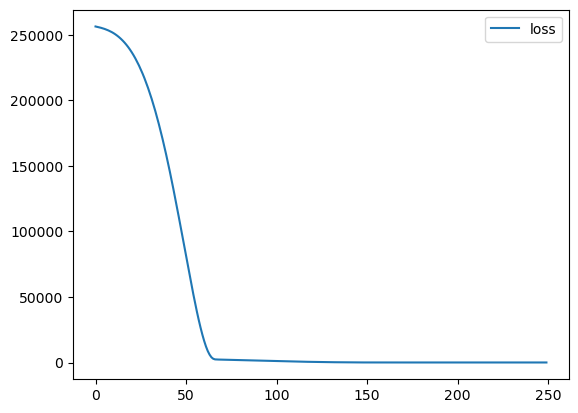

In [175]:
loss_df.plot()

In [176]:
model.evaluate(X_test, y_test, verbose = 0)

24.966896057128906

In [177]:
model.evaluate(X_train, y_train, verbose = 0)

23.83179473876953

In [178]:
test_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [179]:
test_predictions

array([[405.24832],
       [623.5913 ],
       [592.1643 ],
       [572.26917],
       [366.5837 ],
       [579.2159 ],
       [515.0824 ],
       [459.07947],
       [549.27783],
       [447.4848 ],
       [611.8319 ],
       [548.9409 ],
       [419.06638],
       [408.83585],
       [651.2794 ],
       [437.26465],
       [508.43433],
       [660.0204 ],
       [662.66125],
       [565.5546 ],
       [334.16885],
       [444.81104],
       [382.48495],
       [378.7013 ],
       [566.6246 ],
       [610.65173],
       [532.40753],
       [427.82635],
       [655.52466],
       [414.03427],
       [442.60135],
       [485.1208 ],
       [438.3855 ],
       [681.93665],
       [424.7087 ],
       [417.66095],
       [501.90088],
       [550.4942 ],
       [509.75626],
       [395.33557],
       [618.63574],
       [416.5848 ],
       [604.4888 ],
       [445.91855],
       [501.98984],
       [581.723  ],
       [669.05255],
       [490.38843],
       [318.48947],
       [485.42285],


In [180]:
test_predictions = pd.Series(test_predictions.reshape(300,))

In [181]:
test_predictions

0      405.248322
1      623.591309
2      592.164307
3      572.269165
4      366.583710
          ...    
295    529.067505
296    515.377808
297    609.694580
298    416.906830
299    410.846375
Length: 300, dtype: float32

In [182]:
pred_df = pd.DataFrame(y_test, columns = ['Test True Y'])

In [183]:
pred_df

,Test True Y
0,402.296319
1,624.156198
2,582.455066
3,578.588606
4,371.224104
...,...
295,525.704657
296,502.909473
297,612.727910
298,417.569725


In [184]:
pred_df = pd.concat([pred_df, test_predictions], axis = 1)

In [185]:
pred_df.columns = ['Test True Y', 'Model Predictions']

In [186]:
pred_df

,Test True Y,Model Predictions
0,402.296319,405.248322
1,624.156198,623.591309
2,582.455066,592.164307
3,578.588606,572.269165
4,371.224104,366.583710
...,...,...
295,525.704657,529.067505
296,502.909473,515.377808
297,612.727910,609.694580
298,417.569725,416.906830


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

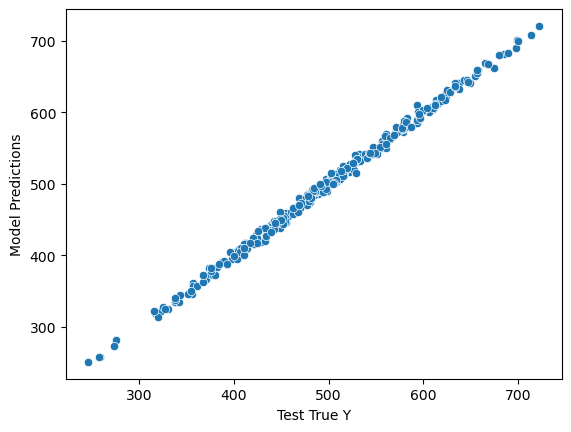

In [187]:
sns.scatterplot(x = 'Test True Y', y = 'Model Predictions',data = pred_df)

In [188]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [189]:
mean_absolute_error(pred_df['Test True Y'], pred_df['Model Predictions'])

4.001313927697377

In [190]:
df.describe()

,price,feature1,feature2
count,1000.000000,1000.000000,1000.000000
mean,498.673029,1000.014171,999.979847
std,93.785431,0.974018,0.948330
min,223.346793,997.058347,996.995651
25%,433.025732,999.332068,999.316106
50%,502.382117,1000.009915,1000.002243
75%,564.921588,1000.637580,1000.645380
max,774.407854,1003.207934,1002.666308


In [191]:
mean_squared_error(pred_df['Test True Y'], pred_df['Model Predictions'])

24.9668989031076

In [192]:
mean_squared_error(pred_df['Test True Y'], pred_df['Model Predictions']) **0.5

4.996688793902178

In [193]:
new_gem = [[998, 1000]]

In [194]:
new_gem = scaler.transform(new_gem)

In [195]:
model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[419.67465]], dtype=float32)

In [196]:
from tensorflow.keras.models import load_model

In [199]:
model.save('my_gem_model.keras')

In [200]:
later_model = load_model('my_gem_model.keras')

In [201]:
later_model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[419.67465]], dtype=float32)